## Подключение зависимостей

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

df = pd.read_csv('../data/ecommerce_dataset.csv')

## Информация по датасету

In [2]:
print("Размер:", df.shape)
print("\nСтатистика:")
print(df.describe())
print("\nПервые 5 строк:")
print(df.head(5))

Размер: (10000, 18)

Статистика:
       transaction_id   customer_id           age  product_price  \
count     10000.00000  10000.000000  10000.000000   10000.000000   
mean       5000.50000   3010.561100     34.317800      49.658060   
std        2886.89568   1152.371939     15.164373      50.400883   
min           1.00000   1000.000000    -25.000000       0.010000   
25%        2500.75000   2001.750000     24.000000      14.320000   
50%        5000.50000   3004.000000     34.000000      33.965000   
75%        7500.25000   4010.000000     45.000000      68.390000   
max       10000.00000   4999.000000     88.000000     460.360000   

           quantity  discount_percent  discount_amount  total_amount  \
count  10000.000000      10000.000000     10000.000000  10000.000000   
mean       5.014700          9.956500        24.500121    249.834238   
std        2.577547          7.079945        41.216654    311.488395   
min        1.000000          0.000000         0.000000      0.0100

In [3]:
print("Пропуски до обработки:\n", df.isnull().sum())
print("Дубликатов:", df.duplicated().sum())


Пропуски до обработки:
 transaction_id             0
date                       0
customer_id                0
age                        0
gender                     0
product_category           0
product_price              0
quantity                   0
discount_percent           0
discount_amount            0
total_amount               0
final_amount               0
payment_method             0
shipping_days              0
customer_rating            0
is_returned                0
region                     0
customer_lifetime_value    0
dtype: int64
Дубликатов: 0


## Обработка пропусков

In [4]:
df['product_price'] = df['product_price'].fillna(df['product_price'].median())
df['quantity'] = df['quantity'].fillna(df['quantity'].median())
df['discount_percent'] = df['discount_percent'].fillna(0)
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])
df['region'] = df['region'].fillna(df['region'].mode()[0])

## Приведение типов дат

In [5]:
df['date'] = pd.to_datetime(df['date'], format='%m-%d-%y', errors='coerce')

print(f"Некорректных дат: {df['date'].isna().sum()}")
if df['date'].isna().sum() > 0:
    df = df.dropna(subset=['date'])
    print(f"Удалено строк с некорректной датой: {df['date'].isna().sum()}")

Некорректных дат: 0


## Удаление дубликатов

In [6]:
if 'transaction_id' in df.columns:
    df.drop_duplicates(subset=['transaction_id'], inplace=True)
else:
    df.drop_duplicates(inplace=True)

## Создание признаков

In [7]:
df['total_amount'] = df['quantity'] * df['product_price']
df['discount_amount'] = df['total_amount'] * (df['discount_percent'] / 100)
df['final_amount'] = df['total_amount'] - df['discount_amount']

## Обработка выбросов

In [8]:
Q1 = df['final_amount'].quantile(0.25)
Q3 = df['final_amount'].quantile(0.75)
IQR = Q3 - Q1
df_clean = df[(df['final_amount'] >= Q1 - 1.5*IQR) & 
              (df['final_amount'] <= Q3 + 1.5*IQR)]
df_clean = df_clean.reset_index(drop=True)

## Сохранение очищенного датасета

In [9]:
df_clean.to_csv('../data/cleaned_ecommerce.csv', index=False)
print(f"Очищенных записей: {len(df_clean)}")

Очищенных записей: 9287


## Таблица "Выручка по месяцам"

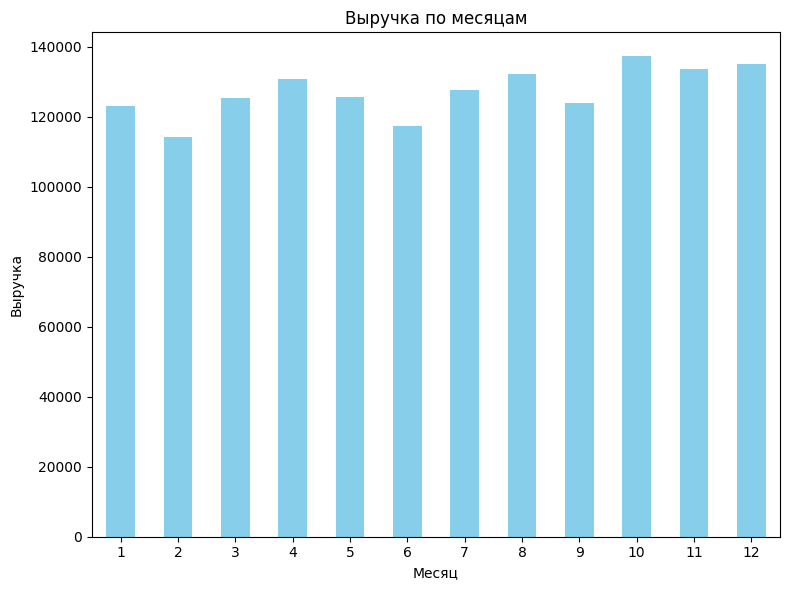

In [10]:

df_clean['order_month'] = df_clean['date'].dt.month
monthly_revenue = df_clean.groupby('order_month')['final_amount'].sum()

plt.figure(figsize=(8,6))
monthly_revenue.plot(kind='bar', color='skyblue')
plt.title('Выручка по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/monthly_revenue.png')
plt.show()

## Таблица "Топ 5 категорий по выручке"

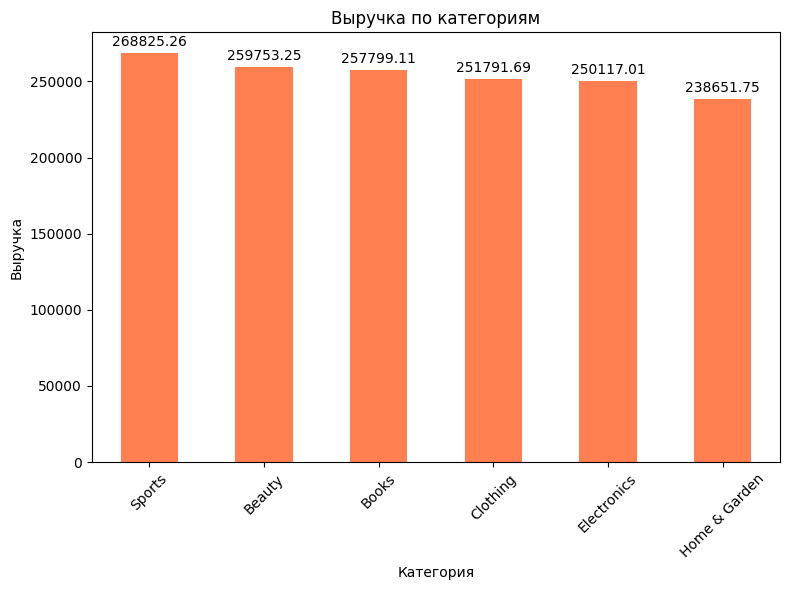

In [11]:
top_categories = df_clean.groupby('product_category')['final_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,6))
ax = top_categories.plot(kind='bar', color='coral')
for p in ax.patches:                     # каждый столбец — это патч
    height = p.get_height()               # высота столбца (значение)
    ax.text(
        p.get_x() + p.get_width() / 2.,   # центр по X
        height + 0.01 * height,           # чуть выше столбца (отступ 1%)
        f'{height:.2f}',                  # текст: два знака после запятой
        ha='center',                      # выравнивание по центру
        va='bottom',                      # привязка снизу
        fontsize=10
    )
plt.title('Выручка по категориям')
plt.xlabel('Категория')
plt.ylabel('Выручка')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/top_categories.png')
plt.show()

## Таблица "Процент от общей доходности по категориям"

In [12]:
category_revenue = df_clean.groupby('product_category')['final_amount'].sum().sort_values(ascending=False)

### Объединение малых категорий в "Другие"

In [13]:
# Объединяем категории с долей < 2% в "Другие"
threshold = 0.02  # 2% от общей выручки
total = category_revenue.sum()
other_revenue = category_revenue[category_revenue / total < threshold].sum()
main_categories = category_revenue[category_revenue / total >= threshold]

if other_revenue > 0:
    main_categories['Другие'] = other_revenue

### Вывод таблицы 

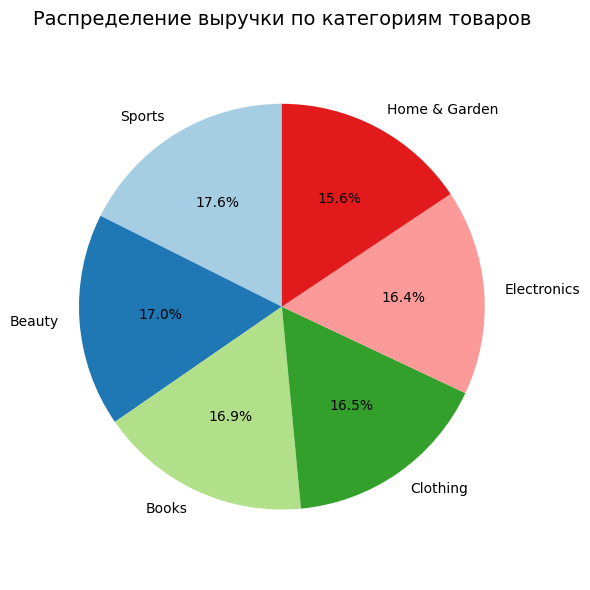

In [14]:
plt.figure(figsize=(6, 6))
plt.pie(
    main_categories,
    labels=main_categories.index,
    autopct='%1.1f%%',          # показываем проценты с одним знаком после запятой
    startangle=90,              # начинаем с 12 часов
    colors=plt.cm.Paired.colors # красивая палитра
)
plt.title('Распределение выручки по категориям товаров', fontsize=14)
plt.axis('equal')               # чтобы круг был круглым
plt.tight_layout()
plt.savefig('../outputs/revenue_by_category_pie.png', dpi=150)
plt.show()

## Таблица "Распределение сумм заказов"

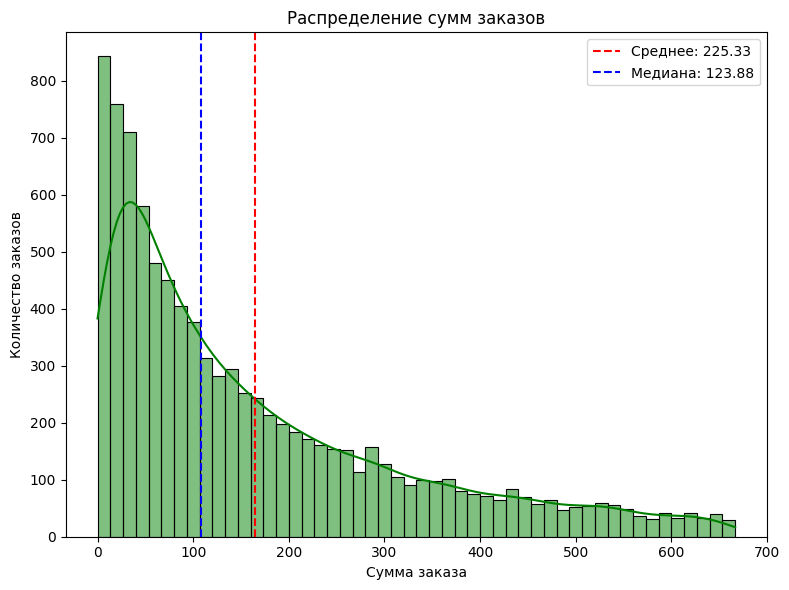

In [15]:
plt.figure(figsize=(8,6))
sns.histplot(df_clean['final_amount'], bins=50, kde=True, color='green')
plt.title('Распределение сумм заказов')
plt.xlabel('Сумма заказа')
plt.ylabel('Количество заказов')
plt.axvline(df_clean['final_amount'].mean(), color='red', linestyle='--', label=f'Среднее: {df["final_amount"].mean():.2f}')
plt.axvline(df_clean['final_amount'].median(), color='blue', linestyle='--', label=f'Медиана: {df["final_amount"].median():.2f}')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/order_distribution.png')
plt.show()

## Таблица "Выручка по регионам"

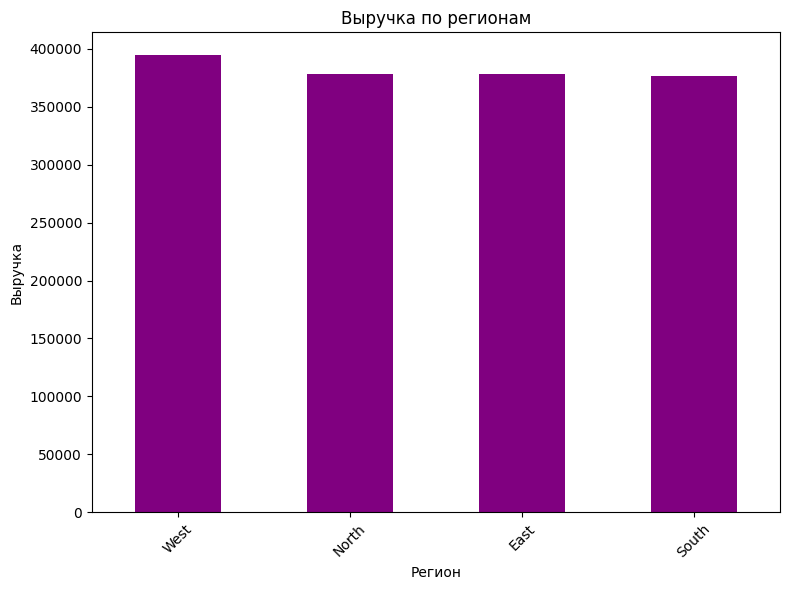

In [16]:
region_revenue = df_clean.groupby('region')['final_amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,6))
region_revenue.plot(kind='bar', color='purple')
plt.title('Выручка по регионам')
plt.xlabel('Регион')
plt.ylabel('Выручка')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/region_revenue.png')
plt.show()

## Таблица "Распределение выручки по регионам"

In [17]:
region_revenue = df_clean.groupby('region')['final_amount'].sum().sort_values(ascending=False)

In [18]:
# Объединяем категории с долей < 2% в "Другие"
threshold = 0.02  # 2% от общей выручки
total = region_revenue.sum()
other_revenue = region_revenue[region_revenue / total < threshold].sum()
main_categories = region_revenue[region_revenue / total >= threshold]

if other_revenue > 0:
    main_categories['Другие'] = other_revenue

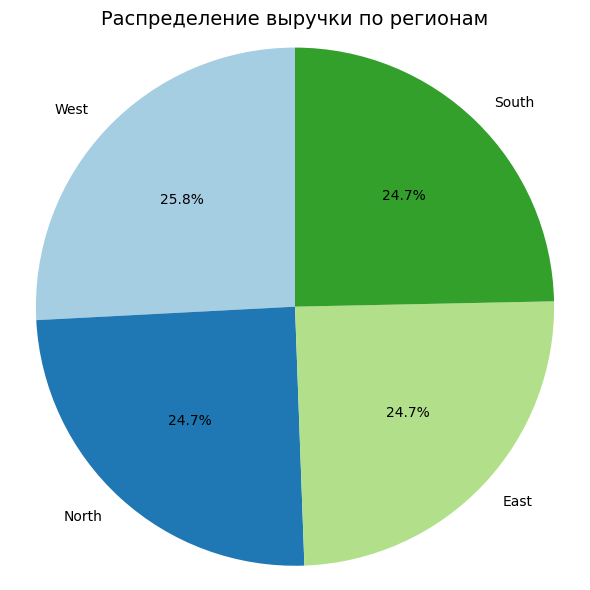

In [19]:
plt.figure(figsize=(6, 6))
plt.pie(
    main_categories,
    labels=main_categories.index,
    autopct='%1.1f%%',          # показываем проценты с одним знаком после запятой
    startangle=90,              # начинаем с 12 часов
    colors=plt.cm.Paired.colors # красивая палитра
)
plt.title('Распределение выручки по регионам', fontsize=14)
plt.axis('equal')               # чтобы круг был круглым
plt.tight_layout()
plt.savefig('../outputs/revenue_by_category_pie.png', dpi=150)
plt.show()

## ML: Предсказание CLV

### **Задача:** Бинарная классификация - определить, "ценный" ли клиент (CLV выше медианы)
**Используемые модели:** 
- Logistic regression
- Random Forest

### Загрузка очищенного датасета

In [20]:

df = pd.read_csv('../data/cleaned_ecommerce.csv')


### Создание целевой переменной

In [21]:
median_clv = df['customer_lifetime_value'].median()
df['high_clv'] = (df['customer_lifetime_value'] >= median_clv).astype(int)

### Создание month feature для учета сезонности

In [22]:
df['order_month'] = pd.to_datetime(df['date']).dt.month

X = df.drop(columns=['customer_lifetime_value', 'high_clv', 'transaction_id', 'date'])
y = df['high_clv']

# Разделение
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Определение категоральных и числовых колонок

In [23]:
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()


### Создание препроцессора

In [24]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', 'passthrough', num_cols)
])

### Применение препроцессора к тренировочным и тестовым выборкам

In [25]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print(f"Размер X_train_processed: {X_train_processed.shape}")
print(f"Размер X_test_processed:  {X_test_processed.shape}")

Размер X_train_processed: (7429, 27)
Размер X_test_processed:  (1858, 27)


### Получение имён признаков для интерпретации

In [26]:
feature_names = (preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist() + 
                 num_cols)
print(f"Всего признаков после кодирования: {len(feature_names)}")
print("Первые 10 признаков:", feature_names[:10])

Всего признаков после кодирования: 27
Первые 10 признаков: ['gender_Female', 'gender_Male', 'gender_Other', 'product_category_Beauty', 'product_category_Books', 'product_category_Clothing', 'product_category_Electronics', 'product_category_Home & Garden', 'product_category_Sports', 'payment_method_Credit Card']


### Обучение логистической регрессии

In [27]:
lr = LogisticRegression(solver='liblinear', max_iter=2000, random_state=42)
lr.fit(X_train_processed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,2000
,multi_class,'deprecated'


### Обучение "случайного леса" (random forest)

In [28]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_processed, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Предсказания для обеих моделей

In [29]:
y_pred_lr = lr.predict(X_test_processed)
y_proba_lr = lr.predict_proba(X_test_processed)[:, 1]

y_pred_rf = rf.predict(X_test_processed)
y_proba_rf = rf.predict_proba(X_test_processed)[:, 1]

### Импорт метрик

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

### Определение функции оценки

In [31]:
def evaluate_model(y_true, y_pred, y_proba, model_name):
    print(f"\n{'='*50}")
    print(f"Модель: {model_name}")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

### Оценка логистической регрессии

In [32]:
evaluate_model(y_test, y_pred_lr, y_proba_lr, "Logistic Regression")


Модель: Logistic Regression
Accuracy:  0.6012
Precision: 0.6322
Recall:    0.4860
F1-score:  0.5495
ROC-AUC:   0.6301

Confusion Matrix:
[[665 263]
 [478 452]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.72      0.64       928
           1       0.63      0.49      0.55       930

    accuracy                           0.60      1858
   macro avg       0.61      0.60      0.60      1858
weighted avg       0.61      0.60      0.60      1858



### Оценка random forest

In [33]:
evaluate_model(y_test, y_pred_rf, y_proba_rf, "Random Forest")


Модель: Random Forest
Accuracy:  0.5899
Precision: 0.6074
Recall:    0.5108
F1-score:  0.5549
ROC-AUC:   0.6224

Confusion Matrix:
[[621 307]
 [455 475]]

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.67      0.62       928
           1       0.61      0.51      0.55       930

    accuracy                           0.59      1858
   macro avg       0.59      0.59      0.59      1858
weighted avg       0.59      0.59      0.59      1858



### Диаграмма признаков для предсказания (Random Forest)

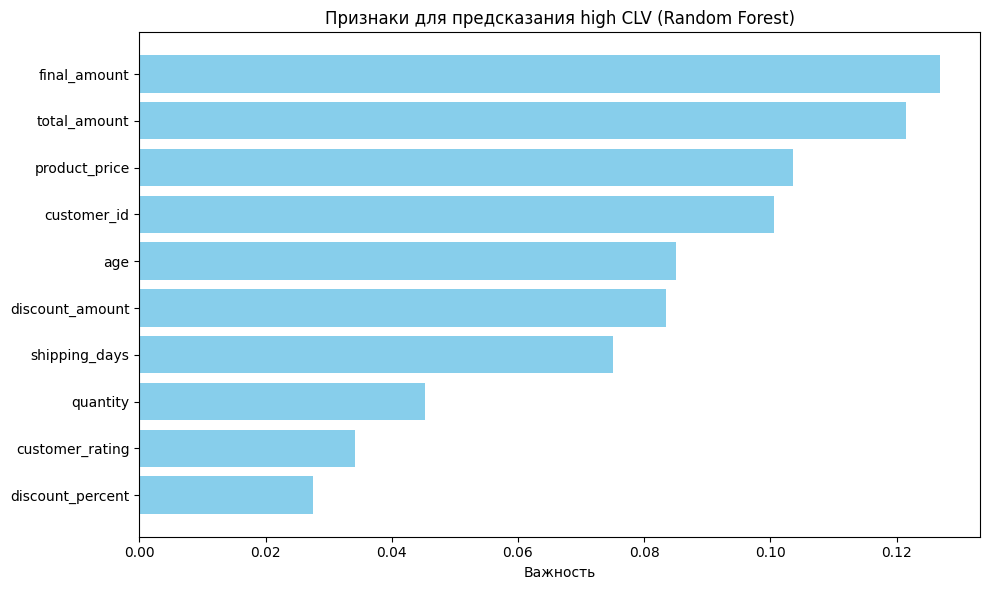

In [34]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:10]  # топ-10

plt.figure(figsize=(10, 6))
plt.barh(range(10), importances[indices][::-1], color='skyblue')
plt.yticks(range(10), [feature_names[i] for i in indices[::-1]])
plt.xlabel('Важность')
plt.title('Признаки для предсказания high CLV (Random Forest)')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png')
plt.show()

### Выводы:
- Обе модели показывают умеренное качество (ROC-AUC ~0.63), что говорит о наличии 
    некоторых закономерностей, но они не очень сильные. Это характерно для синтетических 
    или неглубоких данных.
- Logistic Regression и Random Forest дают близкие результаты, хотя RF чуть лучше 
    по Recall (находит больше ценных клиентов), а LR — по Precision (реже ошибается).
- Наиболее важные признаки для предсказания высокого CLV (по Random Forest):
    - final_amount  — итоговая сумма покупки
    - total_amount  — сумма до скидки
    - product_price — цена товара

**Ограничения:**
   - Признаки не масштабировались, что могло сказаться на сходимости LR.
   - Данные синтетические — в реальных проектах зависимости могут быть сильнее.
   - Дисбаланс классов отсутствует (медианное деление даёт примерно 50/50), 
     поэтому балансировка не требовалась.

**Что можно улучшить:**
   1. Добавить нормализацию числовых признаков для LR — это может повысить ROC-AUC.
   2. Создать новые признаки:
        - средний чек на клиента
        - частота покупок
        - общее количество покупок
        - доля товаров со скидкой

## Сохранение моделей и препроцессора

In [35]:
import pickle
import os

# Создаём папку models, если её нет
os.makedirs('../models', exist_ok=True)

# Сохраняем лучшую модель (Random Forest) и препроцессор
with open('../models/rf_clv_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('../models/preprocessor_clv.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)